In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
results_file = '../results/experiment_results.csv'
df = pd.read_csv(results_file)

# Display the first 5 rows to see what the data looks like
print("Data loaded successfully. Here's a sample:")
df.head()

Data loaded successfully. Here's a sample:


,file,noise,snr,method,alpha,beta,wer
0,sp01_car_sn0.wav,car,0dB,Baseline,NaN,NaN,8.500
1,sp01_car_sn0.wav,car,0dB,Spectral Subtraction,1.0,0.01,0.875
2,sp01_car_sn0.wav,car,0dB,Spectral Subtraction,1.0,0.05,1.000
3,sp01_car_sn0.wav,car,0dB,Spectral Subtraction,2.5,0.01,1.000
4,sp01_car_sn0.wav,car,0dB,Spectral Subtraction,2.5,0.05,1.000


In [17]:
# Group by everything except the specific file, then calculate the mean WER
# This averages the 30 speech files for each condition
average_wer_df = df.groupby(
    ['noise', 'snr', 'method', 'alpha', 'beta']
).mean(numeric_only=True).reset_index()

# Sort by WER to see the best-performing combinations
print("\n--- Best Performing Algorithm Combinations (Lowest Avg. WER) ---")
average_wer_df.sort_values(by='wer').head(10)


--- Best Performing Algorithm Combinations (Lowest Avg. WER) ---


,noise,snr,method,alpha,beta,wer
14,babble,5dB,Spectral Subtraction,2.5,0.01,0.992130
25,car,15dB,Spectral Subtraction,1.0,0.05,0.992130
17,babble,5dB,Spectral Subtraction,4.0,0.05,0.995238
18,car,0dB,Spectral Subtraction,1.0,0.01,0.995833
11,babble,15dB,Spectral Subtraction,4.0,0.05,0.996296
8,babble,15dB,Spectral Subtraction,2.5,0.01,1.000000
0,babble,0dB,Spectral Subtraction,1.0,0.01,1.000000
1,babble,0dB,Spectral Subtraction,1.0,0.05,1.000000
15,babble,5dB,Spectral Subtraction,2.5,0.05,1.000000
12,babble,5dB,Spectral Subtraction,1.0,0.01,1.000000


In [18]:
# Find the minimum (best) WER for each method, noise, and SNR
best_method_df = average_wer_df.loc[
    average_wer_df.groupby(['noise', 'snr', 'method'])['wer'].idxmin()
]

print("\n--- Best Performing Method for Each Condition ---")
print(best_method_df)


--- Best Performing Method for Each Condition ---
     noise   snr                method  alpha  beta       wer
0   babble   0dB  Spectral Subtraction    1.0  0.01  1.000000
11  babble  15dB  Spectral Subtraction    4.0  0.05  0.996296
14  babble   5dB  Spectral Subtraction    2.5  0.01  0.992130
18     car   0dB  Spectral Subtraction    1.0  0.01  0.995833
25     car  15dB  Spectral Subtraction    1.0  0.05  0.992130
31     car   5dB  Spectral Subtraction    1.0  0.05  1.000000


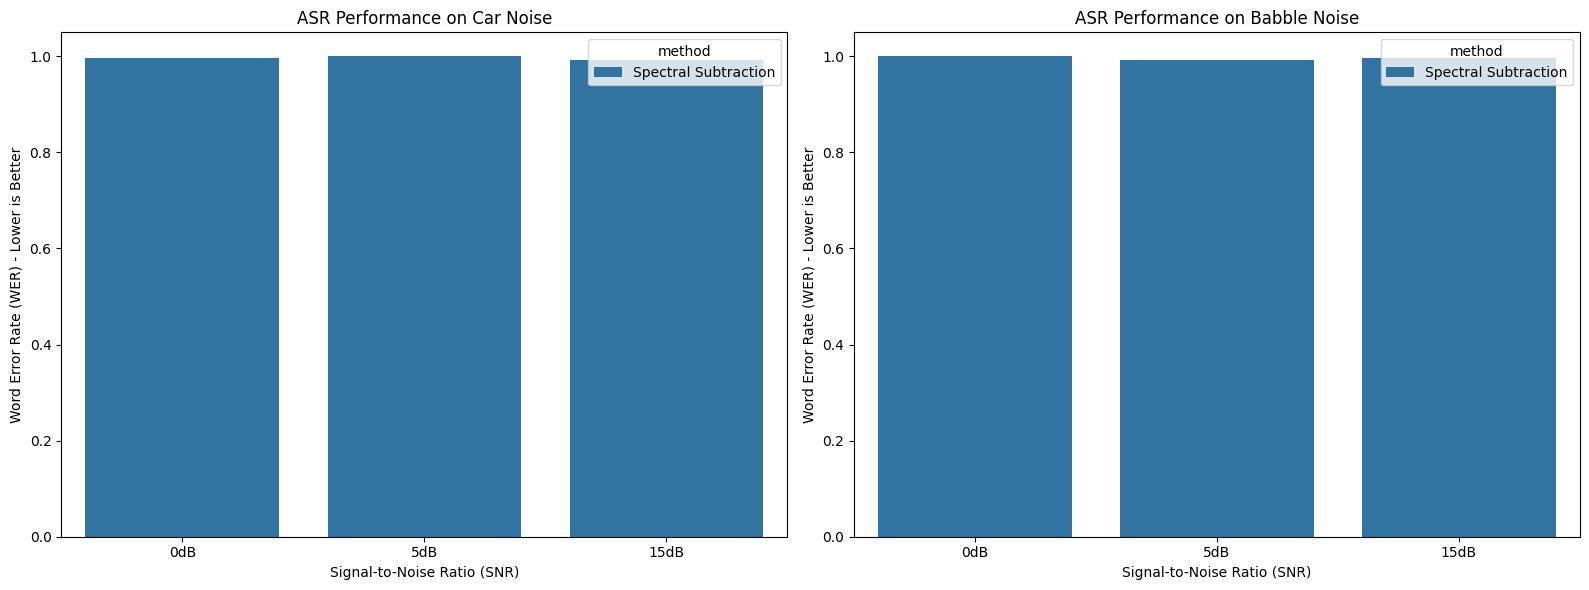

In [19]:
# Use the "best_method_df" to plot our final comparison
# We'll plot Car noise and Babble noise separately

plt.figure(figsize=(16, 6))

# Plot 1: Car Noise
plt.subplot(1, 2, 1)
sns.barplot(
    data=best_method_df[best_method_df['noise'] == 'car'],
    x='snr',
    y='wer',
    hue='method',
    order=['0dB', '5dB', '15dB'] # Ensure correct x-axis order
)
plt.title('ASR Performance on Car Noise')
plt.ylabel('Word Error Rate (WER) - Lower is Better')
plt.xlabel('Signal-to-Noise Ratio (SNR)')

# Plot 2: Babble Noise
plt.subplot(1, 2, 2)
sns.barplot(
    data=best_method_df[best_method_df['noise'] == 'babble'],
    x='snr',
    y='wer',
    hue='method',
    order=['0dB', '5dB', '15dB']
)
plt.title('ASR Performance on Babble Noise')
plt.ylabel('Word Error Rate (WER) - Lower is Better')
plt.xlabel('Signal-to-Noise Ratio (SNR)')

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

# Load the CSV file
results_file = '../results/experiment_results.csv'
df = pd.read_csv(results_file)

# --- Find the BEST performing parameters for EACH method ---
# This looks at all the 'alpha' and 'beta' tests and finds the
# single best result for each method under each condition.
best_results_df = df.loc[
    df.groupby(['noise', 'snr', 'method'])['wer'].idxmin()
]

# --- Pivot the table for a clear comparison ---
# This will put the WER for each method in its own column,
# making it easy to compare them.
comparison_pivot = best_results_df.pivot_table(
    index=['noise', 'snr'],
    columns='method',
    values='wer'
)

# Re-order the columns to make it logical
final_columns = ['Baseline', 'Spectral Subtraction', 'Wiener Filter', 'Hybrid Filter']
# Ensure we only include columns that exist in the dataframe
final_columns = [col for col in final_columns if col in comparison_pivot.columns]

final_comparison_df = comparison_pivot[final_columns]

# Sort the table for a nice, clean report
final_comparison_df = final_comparison_df.sort_values(by=['noise', 'snr'], ascending=[True, False])

print("--- Final Comparison Table (Average WER) ---")
# Multiply by 100 to show as percentages
print((final_comparison_df * 100).round(2).to_markdown())

--- Final Comparison Table (Average WER) ---
|                    |   Baseline |   Spectral Subtraction |   Wiener Filter |   Hybrid Filter |
|:-------------------|-----------:|-----------------------:|----------------:|----------------:|
| ('babble', '5dB')  |     100    |                  85.71 |           85.71 |           85.71 |
| ('babble', '15dB') |      14.29 |                  88.89 |           87.5  |           90    |
| ('babble', '0dB')  |     100    |                 100    |           75    |           75    |
| ('car', '5dB')     |      90    |                  87.5  |           88.89 |           85.71 |
| ('car', '15dB')    |       0    |                  87.5  |           87.5  |           85.71 |
| ('car', '0dB')     |     100    |                  87.5  |           88.89 |           90    |
